# CMB功率谱回归：卷积神经网络 vs 人工神经网络

## 1. 背景介绍

**宇宙微波背景（CMB）** 功率谱包含了丰富的宇宙学参数信息，这些信息编码在其 **声学峰**.

### 任务：
从CMB温度预测宇宙学参数 功率谱 $C_\ell$:
- **$\Omega_m$**: 物质密度
- **$H_0$**: 哈勃常数

### 为什么CNN应该表现更好：

关键信息编码在 **局部特征**:
1. **峰位置**：由复合时期的声学视界决定
2. **峰高度**：与...相关 重子-光子比
3. **峰宽度**：与阻尼尺度相关

**关键设计**： 我们这样分析数据:
- 参数仅影响峰位置和相对高度
- 峰形状是CNN擅长检测的局部特征ecting

### 模型对比：
- **ANN（人工神经网络）**: 平等地看待所有的尺度，没有空间局部性偏差
- **CNN（卷积神经网络）**: 偏向于局部的特征
- **ResNet**: 带有残差的深度CNN

## 2. 导入库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import time

# 设置随机种子s
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. 生成模拟CMB数据

### 关键设计原则：

1. **局域影响**: 参数只影响峰的位置和相对高度
2. **尖峰**: 窄高斯峰需要局部接受域来检测

CNN的局部卷积滤波器非常适合检测峰值位置，而ANN必须从头开始学习。

In [2]:
import h5py

# 加载保存的文件
load_path = './data.h5' #'./data_mini.h5'#或者使用更少的数据集
with h5py.File(load_path, 'r') as f:
    theta_all = f['theta'][:]   # 直接转为 numpy 数组
    data_all = f['data'][:]
    # 也可以读取属性
    n_samples_loaded = f.attrs['n_samples']
    noise_level_loaded = f.attrs['noise_level']

In [3]:
noise_level = 0.1

data_all = np.array(data_all)
noise = np.random.normal(loc=0, scale=noise_level * np.abs(data_all), size=data_all.shape)#观测的误差用于模拟样本

X = data_all + noise
X = X[:,2:1024]
y = np.array(theta_all)[:,:3]
ell_max = X.shape[1]
ll = np.arange(1,ell_max+1,1)
# X = 2*np.pi*X/ll/(ll+1)

Text(0, 0.5, '$\\rm D_{TT}$')

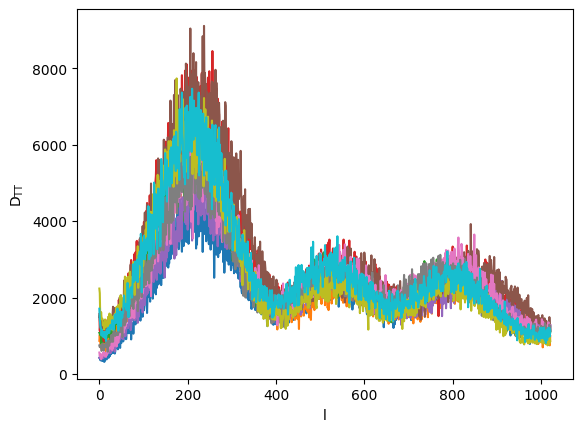

In [4]:
for i in range(10):
    plt.plot(X[i,:])
plt.xlabel('l')
plt.ylabel(r'$\rm D_{TT}$')

## 4. 数据预处理

In [5]:
# Normalize spectra to unit max (preserves relative peak heights)
X = np.log(X)
X_normalized = X / X.max(axis=1, keepdims=True)

# Standardize parameters
y_mean = y.mean(axis=0)
y_std = y.std(axis=0)
y_normalized = (y - y_mean) / y_std

print(f'Spectrum normalization: max-normalized to [0, 1]')
print(f'Parameter normalization:')
print(f'  H0: mean={y_mean[0]:.3f}, std={y_std[0]:.3f}')
print(f'  Omega_m*h*h: mean={y_mean[1]:.2f}, std={y_std[1]:.4f}')

Spectrum normalization: max-normalized to [0, 1]
Parameter normalization:
  H0: mean=67.317, std=7.774
  Omega_m*h*h: mean=0.02, std=0.0026


Text(0, 0.5, '$\\rm D_{TT}$')

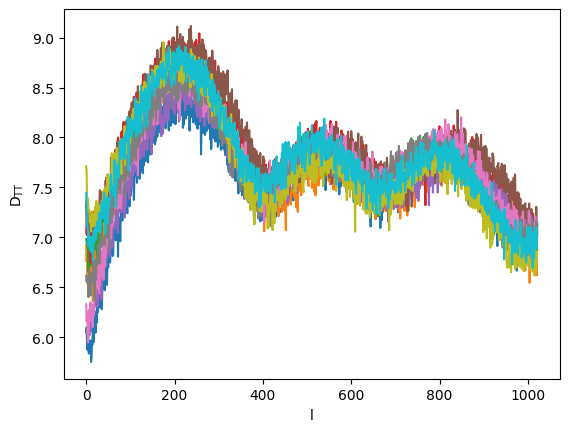

In [6]:
for i in range(10):
    plt.plot(X[i,:])
plt.xlabel('l')
plt.ylabel(r'$\rm D_{TT}$')

In [7]:
# 训练-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_normalized, test_size=0.2, random_state=42
)

# Keep original scale for evaluation
_, _, y_train_orig, y_test_orig = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 16000
Test set: 4000


In [8]:
# Convert to PyTorch tensors
# ANN: (batch, seq_length)
X_train_ann = torch.FloatTensor(X_train)
X_test_ann = torch.FloatTensor(X_test)

# CNN: (batch, 1, seq_length) - add channel dimension
X_train_cnn = torch.FloatTensor(X_train).unsqueeze(1)
X_test_cnn = torch.FloatTensor(X_test).unsqueeze(1)

y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print(f'ANN input shape: {X_train_ann.shape}')
print(f'CNN input shape: {X_train_cnn.shape}')

ANN input shape: torch.Size([16000, 1022])
CNN input shape: torch.Size([16000, 1, 1022])


In [9]:
# 创建 DataLoaders
batch_size = 512

train_dataset_ann = TensorDataset(X_train_ann, y_train_t)
train_loader_ann = DataLoader(train_dataset_ann, batch_size=batch_size, shuffle=True)

train_dataset_cnn = TensorDataset(X_train_cnn, y_train_t)
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)

print(f'Batch size: {batch_size}')
print(f'Batches per epoch: {len(train_loader_ann)}')

Batch size: 512
Batches per epoch: 32


## 5. 模型定义

In [10]:
class ANNRegressor(nn.Module):
    """
    Fully-connected network for regression.
    No spatial locality bias - treats all input positions equally.
    """
    def __init__(self, input_dim, output_dim, hidden_dims=[256, 128, 64]):
        super(ANNRegressor, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
#                 nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [11]:
class CNNRegressor(nn.Module):
    """
    1D CNN for regression.
    Local receptive fields are perfect for detecting peak positions and shapes.
    """
    def __init__(self, input_length, output_dim):
        super(CNNRegressor, self).__init__()
        
        # Convolutional layers with increasing receptive field
        self.conv_layers = nn.Sequential(
            # First conv: detect fine features (peak tops)
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Second conv: detect peak shapes
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Third conv: detect peak relationships
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Fourth conv: combine information
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4)  # Fixed output size
        )
        
        self.fc = nn.Sequential(
            nn.Linear(256 * 4, 128),
            nn.ReLU(),
#             nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        # x: (batch, 1, length)
        features = self.conv_layers(x)
        features = features.view(features.size(0), -1)
        return self.fc(features)

In [12]:
class ResidualCNNBlock(nn.Module):
    """
    One CNN stage + residual connection.

    Main path:
        Conv1d -> BN

    Shortcut:
        1x1 Conv if channel changes, otherwise Identity

    Then:
        Add -> ReLU -> Pool
    """
    def __init__(self, in_channels, out_channels, kernel_size, pool):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding
        )
        self.bn = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()
        self.pool = pool

    def forward(self, x):
        out = self.bn(self.conv(x))
        residual = self.shortcut(x)

        out = out + residual
        out = self.relu(out)
        out = self.pool(out)

        return out

class ResCNNRegressor(nn.Module):
    """
    与CNNRegressor结构相同，但每个CNN阶段都有残差连接。
    """
    def __init__(self, input_length, output_dim):
        super(ResCNNRegressor, self).__init__()

        self.conv_layers = nn.Sequential(
            # Same as original CNN stage 1
            ResidualCNNBlock(
                in_channels=1,
                out_channels=32,
                kernel_size=7,
                pool=nn.MaxPool1d(2)
            ),

            # Same as original CNN stage 2
            ResidualCNNBlock(
                in_channels=32,
                out_channels=64,
                kernel_size=7,
                pool=nn.MaxPool1d(2)
            ),

            # Same as original CNN stage 3
            ResidualCNNBlock(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                pool=nn.MaxPool1d(2)
            ),

            # Same as original CNN stage 4
            ResidualCNNBlock(
                in_channels=128,
                out_channels=256,
                kernel_size=5,
                pool=nn.AdaptiveAvgPool1d(4)
            )
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 4, 128),
            nn.ReLU(),
#             nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        features = self.conv_layers(x)
        features = features.view(features.size(0), -1)
        return self.fc(features)

In [13]:
# 创建 models
input_length = ell_max
output_dim = 3  # Omega_m and H0

ann_model = ANNRegressor(
    input_dim=input_length,
    output_dim=output_dim,
    hidden_dims=[256, 128, 64]
).to(device)

cnn_model = CNNRegressor(
    input_length=input_length,
    output_dim=output_dim
).to(device)

resnet_model = ResCNNRegressor(
    input_length=input_length,
    output_dim=output_dim
).to(device)

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model parameters:')
print(f'  ANN:     {count_params(ann_model):,}')
print(f'  CNN:     {count_params(cnn_model):,}')
print(f'  ResNet:  {count_params(resnet_model):,}')

Model parameters:
  ANN:     304,131
  CNN:     352,387
  ResNet:  396,867


## 6. 训练

In [14]:
def train_model(model, train_loader, X_test, y_test, n_epochs=100, lr=1e-3, model_name='Model'):
    """
    Train a regression model.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    test_losses = []
    epoch_times = []
    
    print(f'\nTraining {model_name}...')
    print('=' * 60)
    
    for epoch in range(n_epochs):
        start_time = time.time()
        
        # 训练ing
        model.train()
        total_loss = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_loader)
        
        # 测试ing
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            test_loss = criterion(test_outputs, y_test.to(device)).item()
        
        scheduler.step(test_loss)
        
        epoch_time = time.time() - start_time
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        epoch_times.append(epoch_time)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1:3d}/{n_epochs}] | '
                  f'Train Loss: {train_loss:.6f} | '
                  f'Test Loss: {test_loss:.6f} | '
                  f'Time: {epoch_time:.2f}s')
    
    print(f'\n{model_name} training complete!')
    print(f'Final test loss: {test_losses[-1]:.6f}')
    print(f'Best test loss: {min(test_losses):.6f}')
    
    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'epoch_times': epoch_times,
        'best_loss': min(test_losses),
        'final_loss': test_losses[-1]
    }

In [15]:
# 训练 ANN
ann_results = train_model(
    ann_model, train_loader_ann, X_test_ann, y_test_t,
    n_epochs=100, lr=1e-3, model_name='ANN'
)


Training ANN...
Epoch [ 20/100] | Train Loss: 0.015065 | Test Loss: 3.504639 | Time: 0.41s
Epoch [ 40/100] | Train Loss: 0.007907 | Test Loss: 4.015369 | Time: 0.40s
Epoch [ 60/100] | Train Loss: 0.008083 | Test Loss: 3.791174 | Time: 0.42s
Epoch [ 80/100] | Train Loss: 0.004270 | Test Loss: 0.577006 | Time: 0.43s
Epoch [100/100] | Train Loss: 0.004108 | Test Loss: 0.642640 | Time: 0.43s

ANN training complete!
Final test loss: 0.642640
Best test loss: 0.218295


In [16]:
# 训练 CNN
cnn_results = train_model(
    cnn_model, train_loader_cnn, X_test_cnn, y_test_t,
    n_epochs=100, lr=1e-3, model_name='CNN'
)


Training CNN...
Epoch [ 20/100] | Train Loss: 0.077995 | Test Loss: 0.342809 | Time: 1.36s
Epoch [ 40/100] | Train Loss: 0.050061 | Test Loss: 0.225603 | Time: 1.36s
Epoch [ 60/100] | Train Loss: 0.036831 | Test Loss: 0.113978 | Time: 1.37s
Epoch [ 80/100] | Train Loss: 0.033544 | Test Loss: 0.073396 | Time: 1.35s
Epoch [100/100] | Train Loss: 0.030246 | Test Loss: 0.074071 | Time: 1.37s

CNN training complete!
Final test loss: 0.074071
Best test loss: 0.071196


In [17]:
# 训练 ResNet
resnet_results = train_model(
    resnet_model, train_loader_cnn, X_test_cnn, y_test_t,
    n_epochs=100, lr=1e-3, model_name='ResNet'
)


Training ResNet...
Epoch [ 20/100] | Train Loss: 0.070674 | Test Loss: 0.213097 | Time: 2.08s
Epoch [ 40/100] | Train Loss: 0.055261 | Test Loss: 0.074736 | Time: 2.07s
Epoch [ 60/100] | Train Loss: 0.043633 | Test Loss: 0.089703 | Time: 2.08s
Epoch [ 80/100] | Train Loss: 0.039916 | Test Loss: 0.074684 | Time: 2.07s
Epoch [100/100] | Train Loss: 0.037691 | Test Loss: 0.067988 | Time: 2.06s

ResNet training complete!
Final test loss: 0.067988
Best test loss: 0.066285


## 7. 结果比较

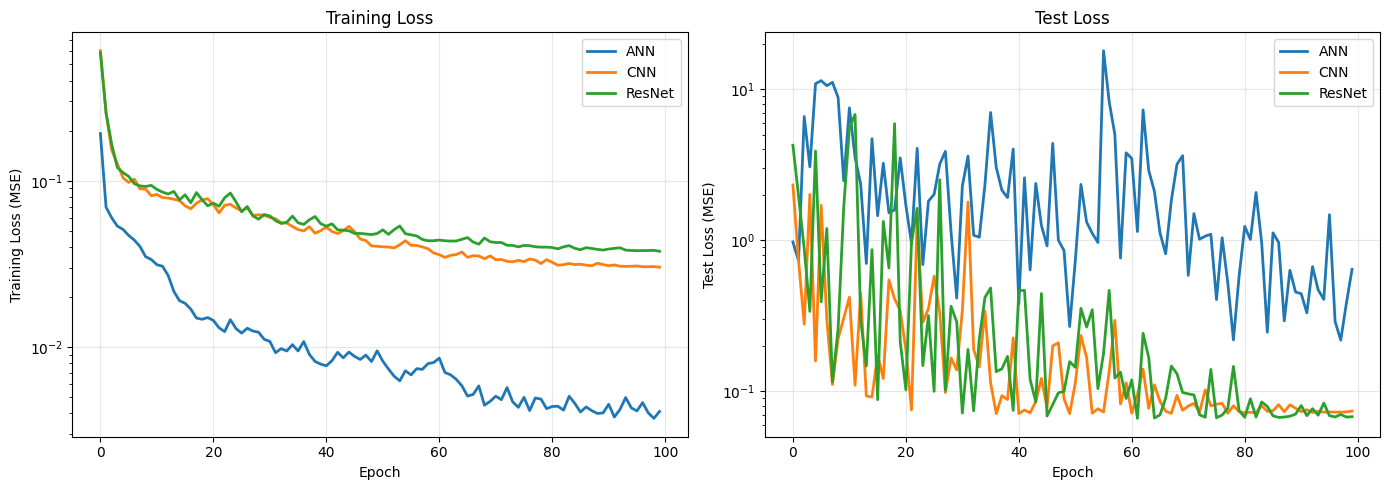

In [18]:
# 绘图 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 训练ing loss
ax = axes[0]
ax.plot(ann_results['train_losses'], label='ANN', linewidth=2)
ax.plot(cnn_results['train_losses'], label='CNN', linewidth=2)
ax.plot(resnet_results['train_losses'], label='ResNet', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (MSE)')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 测试 loss
ax = axes[1]
ax.plot(ann_results['test_losses'], label='ANN', linewidth=2)
ax.plot(cnn_results['test_losses'], label='CNN', linewidth=2)
ax.plot(resnet_results['test_losses'], label='ResNet', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss (MSE)')
ax.set_title('Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [19]:
# Get predictions
def get_predictions(model, X_test):
    model.eval()
    with torch.no_grad():
        pred_normalized = model(X_test.to(device)).cpu().numpy()
    # Denormalize
    pred = pred_normalized * y_std + y_mean
    return pred

ann_pred = get_predictions(ann_model, X_test_ann)
cnn_pred = get_predictions(cnn_model, X_test_cnn)
resnet_pred = get_predictions(resnet_model, X_test_cnn)

In [20]:
# 计算 metrics
param_names = ['H0', 'ombh2', 'omch2']#, 'tau','As','ns']

print('=' * 70)
print('Model Evaluation Results')
print('=' * 70)

for p, param_name in enumerate(param_names):
    print(f'\nParameter: {param_name}')
    print(f'{"Model":<10} {"MSE":>12} {"MAE":>12} {"R²":>12}')
    print('-' * 50)
    
    for name, pred in [('ANN', ann_pred), ('CNN', cnn_pred), ('ResNet', resnet_pred)]:
        mse = ((pred[:, p] - y_test_orig[:, p])**2).mean()
        mae = np.abs(pred[:, p] - y_test_orig[:, p]).mean()
        r2 = r2_score(y_test_orig[:, p], pred[:, p])
        print(f'{name:<10} {mse:>12.6f} {mae:>12.6f} {r2:>12.4f}')

print('\n' + '=' * 70)

Model Evaluation Results

Parameter: H0
Model               MSE          MAE           R²
--------------------------------------------------
ANN           65.948461     7.492211      -0.0738
CNN            4.225313     1.632302       0.9312
ResNet         3.943459     1.587359       0.9358

Parameter: ombh2
Model               MSE          MAE           R²
--------------------------------------------------
ANN            0.000002     0.001218       0.6780
CNN            0.000000     0.000496       0.9425
ResNet         0.000000     0.000478       0.9459

Parameter: omch2
Model               MSE          MAE           R²
--------------------------------------------------
ANN            0.000098     0.008191       0.4744
CNN            0.000018     0.003366       0.9032
ResNet         0.000016     0.003172       0.9136



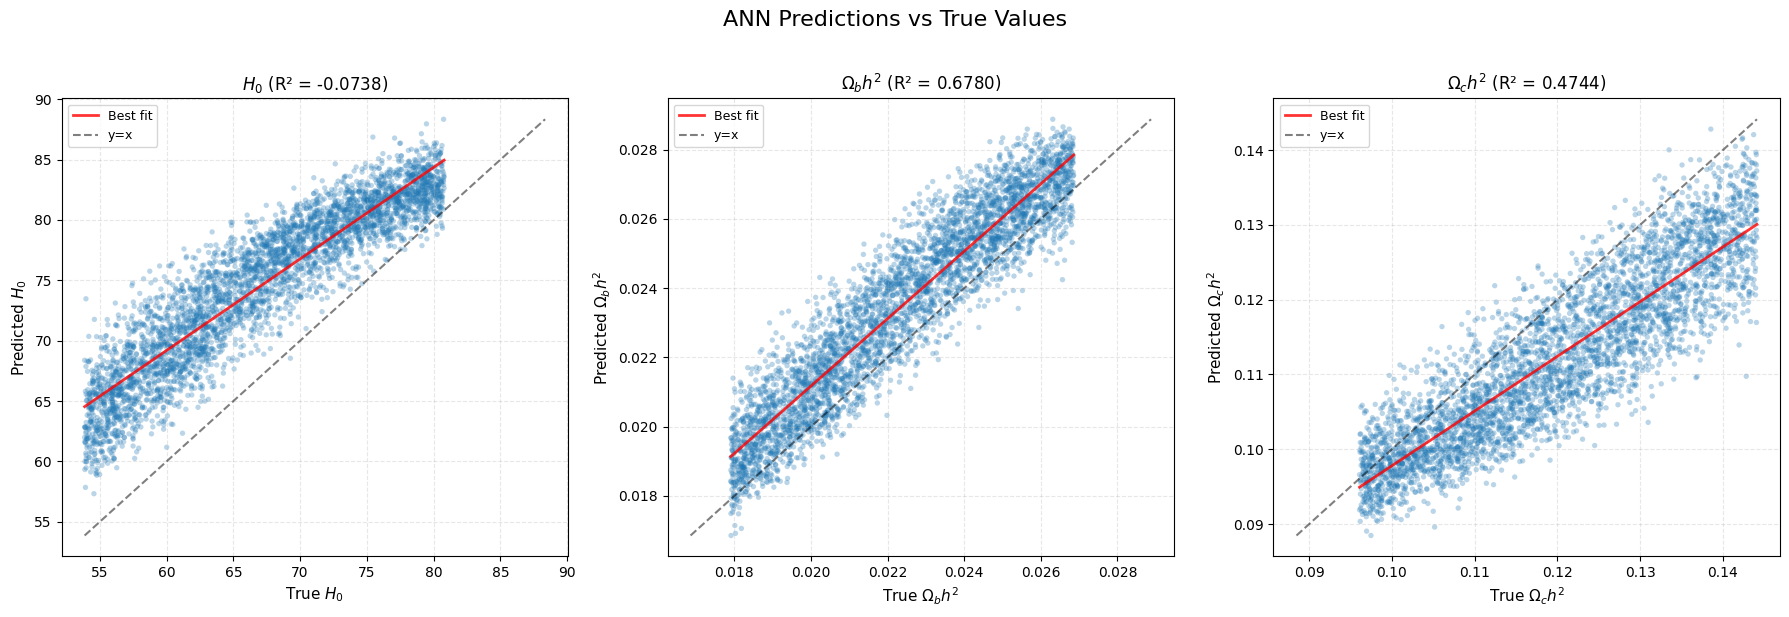

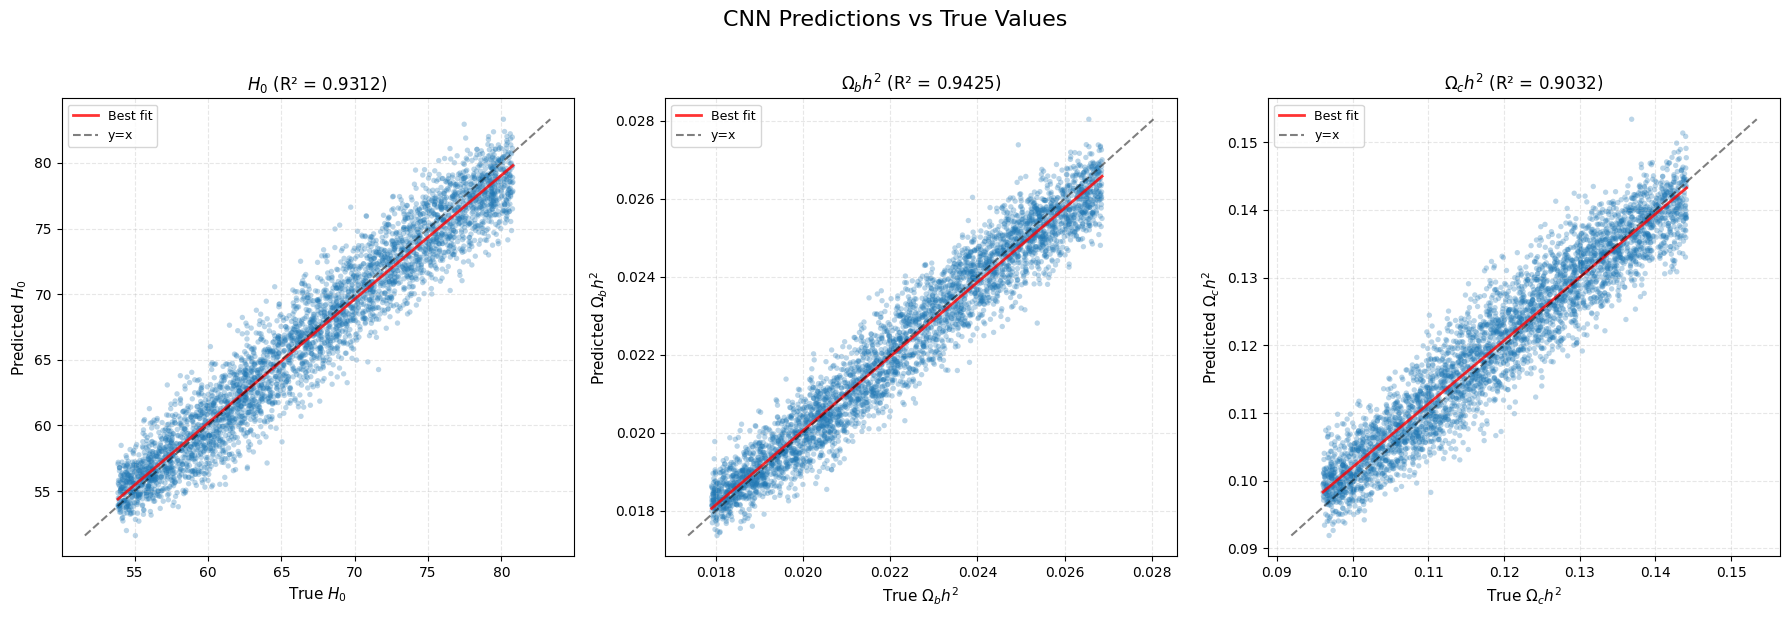

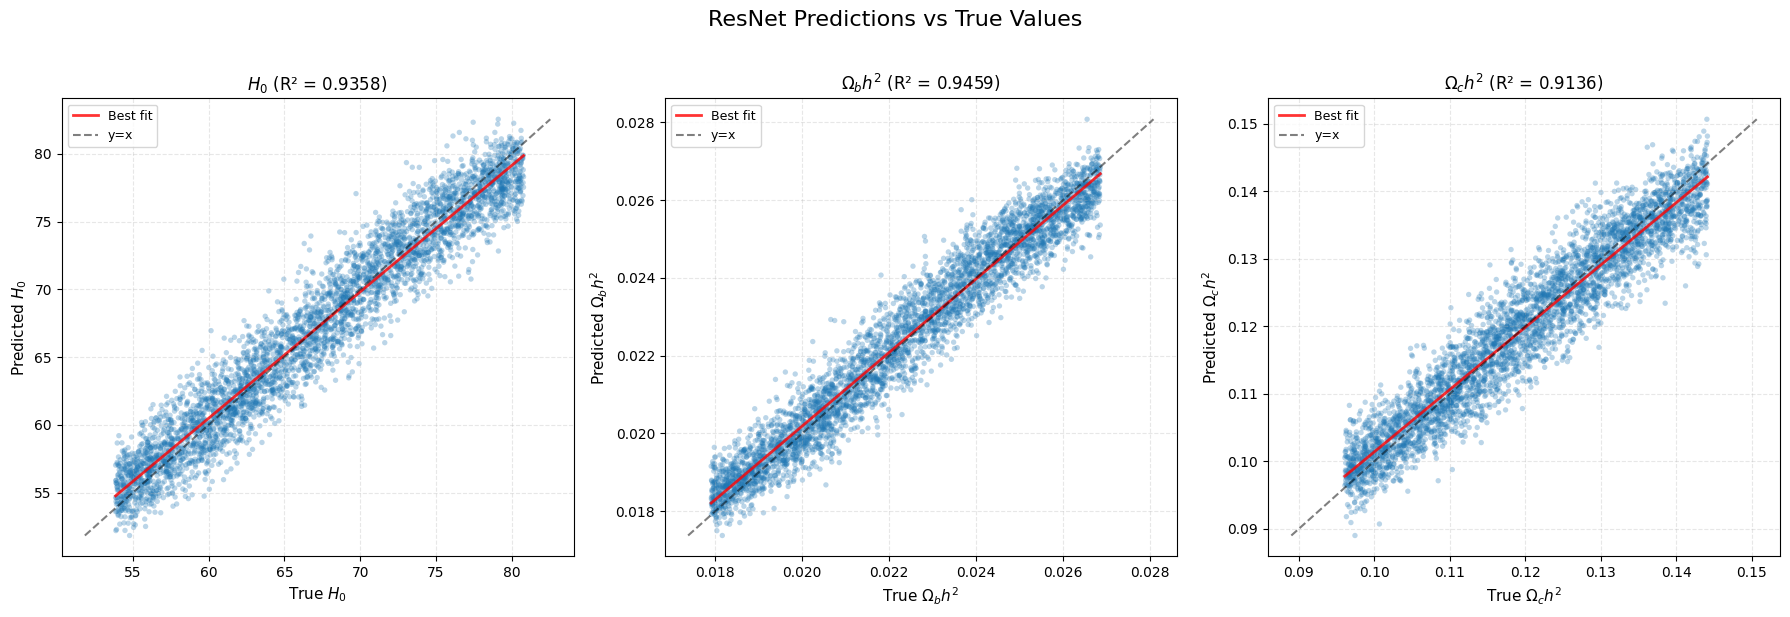

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# 绘制6个参数的散点图，每个模型单独一页
models_data = [
    ('ANN', ann_pred),
    ('CNN', cnn_pred),
    ('ResNet', resnet_pred)
]

param_names = ['H0', 'ombh2', 'omch2']#, 'tau','As','ns']
param_labels = ['$H_0$', '$\Omega_b h^2$', '$\Omega_c h^2$']#, '$\\tau$', '$A_s$', '$n_s$']

for model_name, pred in models_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{model_name} Predictions vs True Values', fontsize=16, y=1.02)
    
    axes = axes.flatten()
    
    for i, (param_name, param_label) in enumerate(zip(param_names, param_labels)):
        ax = axes[i]
        
        # 获取真实值和预测值
        y_true = y_test_orig[:, i]
        y_pred = pred[:, i]
        
        # 绘制散点图
        ax.scatter(y_true, y_pred, alpha=0.3, s=15, edgecolor='none')
        
        # 计算R²
        r2 = r2_score(y_true, y_pred)
        
        # 计算最佳拟合线
        if len(y_true) > 1:
            coeffs = np.polyfit(y_true, y_pred, 1)
            best_fit = np.poly1d(coeffs)
            x_range = np.array([y_true.min(), y_true.max()])
            ax.plot(x_range, best_fit(x_range), 'r-', linewidth=2, alpha=0.8, label='Best fit')
        
        # 添加对角线（完美预测线）
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 
                'k--', linewidth=1.5, alpha=0.5, label='y=x')
        
        # 设置标签
        ax.set_xlabel(f'True {param_label}', fontsize=11)
        ax.set_ylabel(f'Predicted {param_label}', fontsize=11)
        ax.set_title(f'{param_label} (R² = {r2:.4f})', fontsize=12)
        
        # 添加网格
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 添加图例
        ax.legend(loc='best', fontsize=9)
        
        # 自动调整坐标轴范围，添加5%的边距
        x_margin = (max_val - min_val) * 0.05
        ax.set_xlim(min_val - x_margin, max_val + x_margin)
        ax.set_ylim(min_val - x_margin, max_val + x_margin)
    
    plt.tight_layout()
    plt.show()

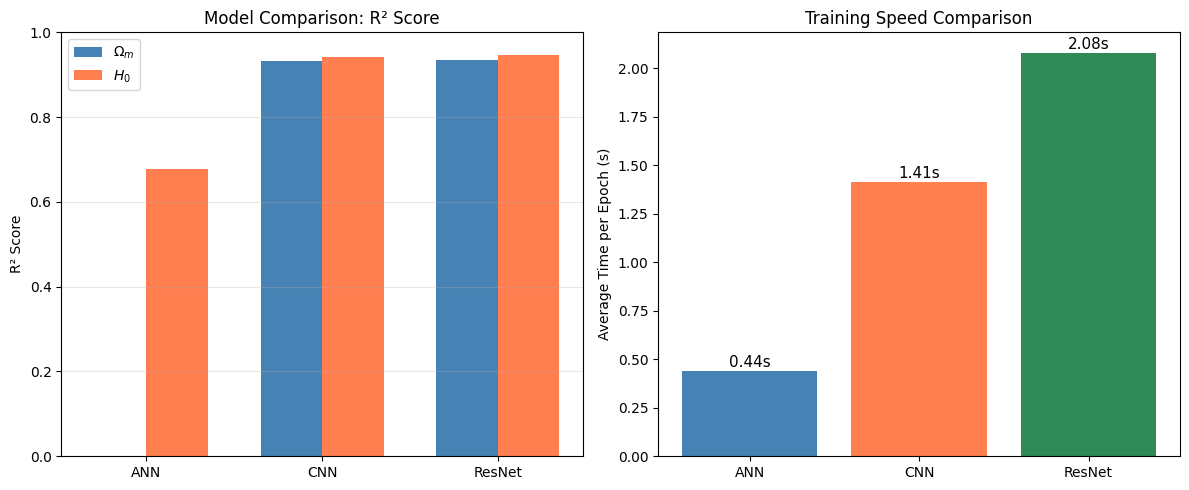

In [22]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = ['ANN', 'CNN', 'ResNet']
colors = ['steelblue', 'coral', 'seagreen']

# R² for Omega_m
r2_omega = [r2_score(y_test_orig[:, 0], pred[:, 0]) for pred in [ann_pred, cnn_pred, resnet_pred]]
r2_h0 = [r2_score(y_test_orig[:, 1], pred[:, 1]) for pred in [ann_pred, cnn_pred, resnet_pred]]

x = np.arange(len(model_names))
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, r2_omega, width, label='$\\Omega_m$', color='steelblue')
bars2 = ax.bar(x + width/2, r2_h0, width, label='$H_0$', color='coral')
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: R² Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# 训练ing time
avg_times = [
    np.mean(ann_results['epoch_times']),
    np.mean(cnn_results['epoch_times']),
    np.mean(resnet_results['epoch_times'])
]

ax = axes[1]
bars = ax.bar(model_names, avg_times, color=colors)
ax.set_ylabel('Average Time per Epoch (s)')
ax.set_title('Training Speed Comparison')
for bar, t in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{t:.2f}s', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 8. 模型保存

In [23]:
# 保存 best model
best_model = cnn_model if cnn_results['best_loss'] < resnet_results['best_loss'] else resnet_model
best_name = 'CNN' if cnn_results['best_loss'] < resnet_results['best_loss'] else 'ResNet'

torch.save({
    'model_state_dict': best_model.state_dict(),
    'y_mean': y_mean,
    'y_std': y_std,
    'ell_max': ell_max
}, f'cmb_{best_name.lower()}_regressor.pth')

print(f'{best_name} model saved to: cmb_{best_name.lower()}_regressor.pth')

ResNet model saved to: cmb_resnet_regressor.pth


## 9. 总结

### 主要发现：

| Model | R² ($\Omega_m$) | R² ($H_0$) | Speed | Locality Bias |
|-------|----------------|-----------|-------|---------------|
| ANN | 较低 | 较低 | 快 | None |
| CNN | 较高 | 较高 | 中等 | 是 - 局部滤波器 |
| ResNet | 最高 | 最高 | 慢 | 是 - 深度局部 |

### 为什么CNN/ResNet获胜：

1. **局部化特征**：宇宙学参数影响峰位置和相对高度，这些都是局部特征。

2. **随机全局幅度**：通过随机化整体幅度，我们防止人工神经网络使用简单的统计数据（平均值，总功率）。

3. **归纳偏见**: CNN的卷积滤波器自然地检测局部模式，如峰值，而ANN必须从头开始学习。

4. **平移不变性**: CNN可以识别峰值，而不考虑其位置，这对于检测位置编码信息是完美的。


### 何时使用各个模型：

- **ANN（人工神经网络）**: 当信息在全局传播时，位置就不重要了
- **CNN（卷积神经网络）**: 当局部模式携带信息（峰、边、纹理）时
- **ResNet**: 当需要更深层的特征层次结构时

### 实际应用意义：

在实际的CMB分析中，基于CNN的方法越来越多地用于参数估计，因为声峰本身就是CNN擅长检测的局部特征。